# Stage 6, Project: Recommendation System

**Problem:** given a user's past movie ratings, recommend movies they haven't seen but are likely to rate highly.

**Dataset:** MovieLens ml-latest-small — 610 users, 9,742 movies, ~100k ratings (1-5 stars, half-star increments), plus genre tags.

New concepts this project introduces: the user-item matrix, matrix factorization (this is where PCA/SVD's eigenvector intuition from Stage 1/4 pays off directly), and ranking-based evaluation (precision@k) instead of the classification metrics from Stage 5.

## 1. Load and first look

Guiding questions:
- How many unique users and movies are there? How does that compare to the number of ratings — what fraction of all possible (user, movie) pairs actually have a rating?
- This fraction has a name: **sparsity**. A user-item matrix where almost every cell is empty is the defining challenge of recommendation systems — keep this number in mind, it explains why naive approaches struggle here.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: load ml-latest-small/ratings.csv and ml-latest-small/movies.csv

url1 = "ml-latest-small/ratings.csv"
url2 = "ml-latest-small/movies.csv"

ratings = pd.read_csv(url1)
movies = pd.read_csv(url2)

ratings.count()
#movies.count()


userId       100836
movieId      100836
rating       100836
timestamp    100836
dtype: int64

In [24]:
# TODO: n_users, n_movies, n_ratings, sparsity = 1 - (n_ratings / (n_users * n_movies))
# print sparsity as a percentage
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = ratings["rating"].count()

sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Sparsity: {sparsity:.2%}")



Sparsity: 98.30%


## 2. EDA

Guiding questions:
- Plot the distribution of ratings per movie. Are most movies rated by very few users, with a small number of blockbusters dominating? (This is the classic "long tail" pattern in recommendation data.)
- Plot the distribution of ratings per user. Do most users rate few movies, with a handful of power-raters?
- Plot the distribution of the rating values themselves (1-5 stars) — any skew?

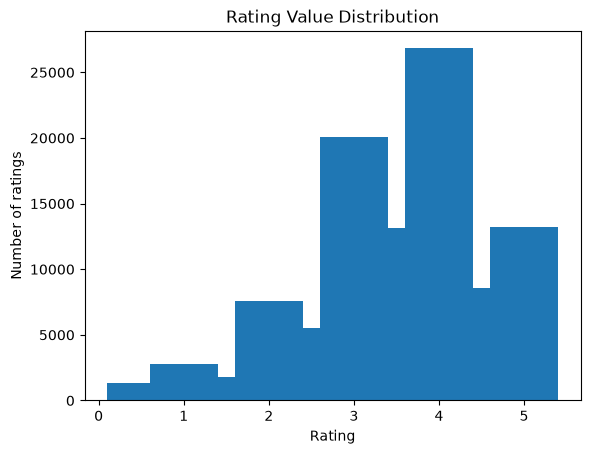

In [32]:
# TODO: ratings-per-movie distribution, ratings-per-user distribution, rating value distribution

ratings_per_movie = ratings.groupby("movieId").size()

#plt.hist(ratings_per_movie)
#plt.xlabel("Number of ratings per movie")
#plt.ylabel("Number of movies")
#plt.title("Ratings per Movie Distribution")
#plt.show()



#ratings_per_user = ratings.groupby("userId").size()
#plt.hist(ratings_per_user)
#plt.xlabel("Number of ratings per user")
#plt.ylabel("Number of users")
#plt.title("Ratings per User Dist.")
#plt.show()

rating_dist = ratings["rating"].value_counts().sort_index()

plt.bar(rating_dist.index, rating_dist.values)
plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Rating Value Distribution")
plt.show()




## 3. Train/test split — different rules for recommenders

This is NOT the same as a normal random row split. If you randomly split individual ratings, some users or movies could end up with zero ratings in train, making them impossible to recommend for/evaluate at all.

The standard approach: for each user, hold out a small number of their ratings (e.g., their most recent, or a random 20%) for testing, keeping the rest in train. This guarantees every user has *some* training history.

Guiding question: why would a purely random split (ignoring per-user grouping) risk leaking information or producing an unfair evaluation here, in a way it didn't for Titanic or house prices?

In [34]:
# TODO: implement a per-user split — for each userId, put ~80% of their ratings in train, ~20% in test
# hint: use groupby('userId') and sample/split within each group

from sklearn.model_selection import train_test_split

train_list = []
test_list = []

for user_id, user_ratings in ratings.groupby("userId"):
    if len(user_ratings) < 2:
        continue

    train, test = train_test_split(
        user_ratings,
        test_size=0.2,
        random_state=42
    )

    train_list.append(train)
    test_list.append(test)

train = pd.concat(train_list)
test = pd.concat(test_list)






## 4. Baseline: Popularity Recommender

The simplest possible recommender: recommend the same top-N most popular (highest average-rated, with a minimum rating-count cutoff to avoid one-rating flukes) movies to every user, regardless of their individual taste.

Guiding question: why is a minimum rating-count cutoff necessary here? (Think about a movie with a single 5-star rating vs. one with 500 ratings averaging 4.5 — which is the more trustworthy "good movie" signal?)

In [ ]:
# TODO: compute average rating per movie on TRAIN data only, filter to movies with e.g. >= 20 ratings,
# sort descending -> this ranked list is your baseline recommender for every user


movie_stats = train.groupby("movieId")["rating"].agg(["mean", "count"]) #aggregate

movie_stats = movie_stats[movie_stats["count"] >= 20] # keep the ones with count>=20

baseline_popularity = movie_stats.sort_values(  #sort
    by="mean",
    ascending=False
)

print(baseline_popularity)

             mean  count
movieId                 
318      4.415663    249
1204     4.348485     33
1276     4.322222     45
922      4.318182     22
898      4.285714     21
...           ...    ...
1562     2.224138     29
1021     2.190476     21
2701     2.182927     41
1882     1.931818     22
1499     1.913043     23

[1059 rows x 2 columns]


## 5. Collaborative Filtering via Matrix Factorization

The core idea: build a user-item matrix (rows = users, columns = movies, values = ratings, mostly empty given your sparsity finding). Then factor that matrix into two smaller matrices — one representing users as vectors in a small "latent taste space," one representing movies the same way — such that multiplying them back together approximates the original ratings, filling in the empty cells with predictions.

This is the direct payoff of Stage 1/4's PCA review: you're finding a lower-dimensional representation that captures the main directions of variation in the data, same underlying idea as PCA, applied to a sparse ratings matrix instead of a dense feature table.

Guiding question: what might a "latent dimension" the model discovers actually represent, conceptually (you'll never see it labeled explicitly, but reason about what kind of pattern would make users and movies align along a shared axis)? E.g., could one latent dimension end up implicitly capturing something like "prefers action movies vs. prefers dramas"?

In [53]:
# TODO: pivot TRAIN ratings into a user-item matrix (pd.pivot_table or pivot), fill missing with 0

user_item_matrix = pd.pivot_table(
    train,
    index="userId",
    columns="movieId",
    values="rating",
    aggfunc="mean",
    fill_value=0
)






In [54]:
from sklearn.decomposition import TruncatedSVD

# TODO: fit TruncatedSVD (try n_components=20 to start) on the user-item matrix
# this gives you user vectors (transform output) and movie vectors (components_)
# reconstruct approximate ratings via user_vectors @ movie_vectors to get predicted scores for EVERY user-movie pair

svd = TruncatedSVD(n_components=20)

user_vectors = svd.fit_transform(user_item_matrix)
movie_vectors = svd.components_

reconstruction = user_vectors @ movie_vectors
print(reconstruction)




[[ 1.76866986e+00  1.29916380e+00  4.52152213e-01 ... -9.90738251e-03
  -9.90738251e-03 -3.54248210e-02]
 [ 1.45762257e-01  2.55561571e-02  4.58321423e-02 ...  5.60147539e-03
   5.60147539e-03  1.31753228e-02]
 [ 5.21173183e-02  4.81324838e-02  2.50184896e-02 ... -4.27252791e-04
  -4.27252791e-04 -2.40789419e-03]
 ...
 [ 3.40709508e+00  1.87171665e+00  9.52108457e-01 ... -2.97059593e-02
  -2.97059593e-02 -1.73522349e-02]
 [ 3.03500057e-01  4.78402837e-01  2.61918290e-01 ... -3.08309283e-04
  -3.08309283e-04 -4.78228324e-04]
 [ 4.52063279e+00  9.31134640e-02 -2.63873934e-01 ...  1.30626817e-02
   1.30626817e-02  2.42248256e-02]]


## 6. Content-Based Filtering

A completely different approach: instead of using other users' ratings, recommend movies similar in *content* (genres) to what a given user has rated highly.

Steps: build a genre feature vector per movie (one-hot the pipe-separated genres column), compute cosine similarity between movies, then for a given user, recommend movies most similar to the ones they've rated highest.

Guiding question: what's a scenario where content-based filtering would work well but collaborative filtering would struggle? (Think about a brand new movie with zero ratings yet — this is called the "cold start" problem.)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: one-hot encode genres per movie (split on '|'), compute cosine similarity matrix between all movies


genres = movies["genres"].str.get_dummies(sep="|")

movie_similarity = cosine_similarity(genres)
print(movie_similarity)



[[1.         0.77459667 0.31622777 ... 0.         0.31622777 0.4472136 ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.         0.         0.70710678]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.31622777 0.         0.         ... 0.         1.         0.        ]
 [0.4472136  0.         0.70710678 ... 0.         0.         1.        ]]


## 7. Evaluation: Precision@K and Recall@K

Standard classification metrics don't directly apply here — there's no single "correct" label per prediction. Instead, recommenders are evaluated by: generate the top-K recommendations for a user, then check how many of the movies they *actually rated highly in the test set* appear in that top-K list.

- **Precision@K** = (relevant items in your top-K) / K
- **Recall@K** = (relevant items in your top-K) / (total relevant items that exist for this user in test)

Guiding question: define "relevant" for this dataset — would you count any rating in the test set as relevant, or only ratings above some threshold (e.g., >= 4 stars)? Justify your choice.

In [59]:
# TODO: implement precision@K and recall@K, evaluate the popularity baseline,
# collaborative filtering, and content-based approaches
# average the per-user precision@K and recall@K across all users for each approach

k = 5


# ------------------------------------------------------------
# Precision@K and Recall@K
# ------------------------------------------------------------

def precision_recall_at_k(recommended, actual, k):
    recommended = recommended[:k]

    hits = len(set(recommended) & set(actual))

    precision = hits / k
    recall = hits / len(actual) if len(actual) > 0 else 0

    return precision, recall


# ------------------------------------------------------------
# Collaborative Filtering Recommendations
# ------------------------------------------------------------

def get_svd_recommendations(user_id, k):

    user_index = user_item_matrix.index.get_loc(user_id)

    # Predicted scores for all movies
    scores = reconstruction[user_index]

    # Movies the user has NOT rated in TRAIN
    unrated = user_item_matrix.iloc[user_index] == 0

    unrated_indices = np.where(unrated)[0]

    # Rank unrated movies by predicted score
    ranked_indices = unrated_indices[
        np.argsort(scores[unrated_indices])[::-1]
    ]

    # Convert matrix indices to movie IDs
    recommended_movies = user_item_matrix.columns[
        ranked_indices[:k]
    ].tolist()

    return recommended_movies


# ------------------------------------------------------------
# Content-Based Recommendations
# ------------------------------------------------------------

def get_content_recommendations(user_id, k):

    # Get user's TRAIN ratings
    user_train = train[train["userId"] == user_id]

    # Movies the user liked
    liked_movies = user_train[
        user_train["rating"] >= 4
    ]["movieId"].tolist()

    scores = np.zeros(len(movies))

    # Find movies similar to movies the user liked
    for movie_id in liked_movies:

        movie_index = movies.index[
            movies["movieId"] == movie_id
        ][0]

        scores += movie_similarity[movie_index]

    # Don't recommend movies already rated
    rated_movies = set(user_train["movieId"])

    ranked_indices = np.argsort(scores)[::-1]

    recommended_movies = []

    for index in ranked_indices:

        movie_id = movies.iloc[index]["movieId"]

        if movie_id not in rated_movies:
            recommended_movies.append(movie_id)

        if len(recommended_movies) == k:
            break

    return recommended_movies


# ------------------------------------------------------------
# Evaluate all three approaches
# ------------------------------------------------------------

results = {}

for approach in ["Popularity", "Collaborative", "Content-Based"]:

    precisions = []
    recalls = []

    for user_id in test["userId"].unique():

        # Movies the user actually liked in TEST
        user_test = test[test["userId"] == user_id]

        actual = set(
            user_test[user_test["rating"] >= 4]["movieId"]
        )

        # Skip users with no relevant test movies
        if len(actual) == 0:
            continue


        # Get recommendations
        if approach == "Popularity":

            recommended = baseline_popularity.index[:k].tolist()

        elif approach == "Collaborative":

            # Only users that exist in the training matrix
            if user_id not in user_item_matrix.index:
                continue

            recommended = get_svd_recommendations(user_id, k)

        else:

            recommended = get_content_recommendations(user_id, k)


        # Calculate metrics
        precision, recall = precision_recall_at_k(
            recommended,
            actual,
            k
        )

        precisions.append(precision)
        recalls.append(recall)


    # Average across users
    results[approach] = {
        "Precision@5": np.mean(precisions),
        "Recall@5": np.mean(recalls)
    }


# ------------------------------------------------------------
# Print Results
# ------------------------------------------------------------

for approach, metrics in results.items():

    print(approach)
    print("Precision@5:", metrics["Precision@5"])
    print("Recall@5:", metrics["Recall@5"])
    print()

Popularity
Precision@5: 0.029666666666666668
Recall@5: 0.013293283224544726

Collaborative
Precision@5: 0.25733333333333336
Recall@5: 0.1225638343687235

Content-Based
Precision@5: 0.005
Recall@5: 0.001989177634670677



## 8. Error analysis

Pick a handful of individual users. Look at what they actually rated highly (train set) versus what each approach recommended. Where do the recommendations make intuitive sense, and where do they clearly miss?

In [63]:
# TODO: for 2-3 sample users, print their top-rated train movies alongside top recommendations from each approach


sample_users = [1, 10, 50, 100, 150]

for user_id in sample_users:

    print("=" * 70)
    print("USER:", user_id)
    print("=" * 70)

    # --------------------------------------------------
    # User's highly-rated movies in TRAIN
    # --------------------------------------------------

    user_train = train[train["userId"] == user_id]

    liked_movies = user_train[
        user_train["rating"] >= 4
    ][["movieId", "rating"]]

    liked_movies = liked_movies.merge(
        movies[["movieId", "title"]],
        on="movieId"
    )

    print("\nHighly-rated movies in TRAIN:")
    print(
        liked_movies[
            ["movieId", "title", "rating"]
        ].sort_values("rating", ascending=False).head(10)
    )


    # --------------------------------------------------
    # Popularity recommendations
    # --------------------------------------------------

    popularity_recs = baseline_popularity.index[:5].tolist()

    popularity_titles = movies[
        movies["movieId"].isin(popularity_recs)
    ][["movieId", "title"]]

    print("\nPopularity recommendations:")
    print(popularity_titles)


    # --------------------------------------------------
    # Collaborative / SVD recommendations
    # --------------------------------------------------

    if user_id in user_item_matrix.index:

        svd_recs = get_svd_recommendations(user_id, 5)

        svd_titles = movies[
            movies["movieId"].isin(svd_recs)
        ][["movieId", "title"]]

        print("\nCollaborative (SVD) recommendations:")
        print(svd_titles)


    # --------------------------------------------------
    # Content-based recommendations
    # --------------------------------------------------

    content_recs = get_content_recommendations(user_id, 5)

    content_titles = movies[
        movies["movieId"].isin(content_recs)
    ][["movieId", "title"]]

    print("\nContent-based recommendations:")
    print(content_titles)

USER: 1

Highly-rated movies in TRAIN:
     movieId                                      title  rating
0       1031            Bedknobs and Broomsticks (1971)     5.0
81      2654                       Wolf Man, The (1941)     5.0
107      151                             Rob Roy (1995)     5.0
106     1291  Indiana Jones and the Last Crusade (1989)     5.0
100     1226                      Quiet Man, The (1952)     5.0
98      3273                            Scream 3 (2000)     5.0
96      1029                               Dumbo (1941)     5.0
95      1625                           Game, The (1997)     5.0
94        47                Seven (a.k.a. Se7en) (1995)     5.0
91      2948               From Russia with Love (1963)     5.0

Popularity recommendations:
     movieId                                          title
277      318               Shawshank Redemption, The (1994)
680      898                 Philadelphia Story, The (1940)
704      922  Sunset Blvd. (a.k.a. Sunset Boulev

## Wrap-up

Write a short summary:
- Which approach won on precision@K / recall@K — popularity baseline, collaborative filtering, or content-based?
- Did collaborative filtering meaningfully beat the popularity baseline? If the gap is smaller than you expected, what does that suggest about this dataset's sparsity?
- What would a production recommendation system likely do differently from any single approach here (hint: think about combining approaches, and how you'd handle a brand-new user with zero ratings)?

- The collaborative filtering won with 1.29 / 5 movies recommended being in a user's top 10 rated movies. However, even when it 'won' it was still relativelty low followed by popularity blind baseline and content based.
- The gap was widen enough to demonstrate collabrative filtering meaninfully beat the popularity baseline.
- Collaborative filtering uses user behavior, "users who behaved similarly to you liked these movies, so you may like them as well"
- Content based filtering uses information about the item themselves, using similary generes
- A production recommendation system would likely use a hybrid approach rather than relying on a single method. Collaborative filtering can capture patterns between users, while content-based filtering can recommend items based on the user's known preferences. A popularity-based model could also serve as a fallback. For a brand-new user with no ratings, collaborative filtering would suffer from the cold-start problem, so the system could initially recommend popular movies or ask the user to select a few movies or genres they like. As the user interacts with more movies, the system could gradually transition to more personalized recommendations. 